
# <span style="color:#245A81;">Método de punto fijo</span>
**Algoritmo 2.2 de Burden — Ejemplo 1**

En este cuaderno se aplica el método de punto fijo a la ecuación del ejemplo de la página 38:

$$
x^3+4x^2-10=0
$$



## 1. Preparar la ecuación

Para usar punto fijo, escribimos la ecuación como $x=g(x)$. En la página 46, Burden muestra varias opciones. Aquí usaremos la opción **(d)**:

$$
\boxed{g(x)=\sqrt{\frac{10}{4+x}}}
$$

La aproximación inicial será $p_0=1.5$. La regla del método es

$$
\boxed{p_n=g(p_{n-1})}.
$$

Se detiene cuando $|p_n-p_{n-1}|<TOL$ o cuando se llega al máximo de iteraciones.



## 2. Importar las bibliotecas

`numpy` permite calcular la raíz cuadrada, `pandas` organiza los datos en una tabla y `matplotlib` crea la gráfica.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



## 3. Definir las funciones

`def` crea una función y `return` entrega el resultado. La función `f` es la ecuación original y `g` es la expresión usada para iterar.


In [2]:

def f(x):
    return x**3 + 4*x**2 - 10

def g(x):
    return np.sqrt(10 / (4 + x))



## 4. Comprobar los datos del ejemplo

En el intervalo $[1,2]$, la función original cambia de signo. Esto confirma que la raíz del ejemplo está entre esos valores.


In [3]:

print("f(1) =", f(1))
print("f(2) =", f(2))
print("g(1.5) =", g(1.5))


f(1) = -5
f(2) = 14
g(1.5) = 1.348399724926484



## 5. Código del método de punto fijo

Este código sigue el Algoritmo 2.2: calcula $p=g(p_0)$, compara las dos aproximaciones y actualiza $p_0$. `for` repite el proceso y `abs` calcula el valor absoluto.


In [4]:

def punto_fijo(p0, tol, nmax):
    resultados = []

    for i in range(1, nmax + 1):
        p = g(p0)
        error = abs(p - p0)
        resultados.append([i, p0, p, f(p), error])

        if error < tol:
            tabla = pd.DataFrame(
                resultados,
                columns=["Iteración", "p anterior", "p nuevo", "f(p)", "Diferencia"]
            )
            return p, tabla, True

        p0 = p

    tabla = pd.DataFrame(
        resultados,
        columns=["Iteración", "p anterior", "p nuevo", "f(p)", "Diferencia"]
    )
    return p, tabla, False



## 6. Ejecutar el ejemplo

Usamos $p_0=1.5$, $TOL=10^{-5}$ y un máximo de 100 iteraciones. La tolerancia es el límite para la diferencia entre dos aproximaciones seguidas.


In [5]:

p0 = 1.5
tol = 1e-5
nmax = 100

raiz, tabla, exito = punto_fijo(p0, tol, nmax)

print("¿Se alcanzó la tolerancia?:", exito)
print("Iteraciones:", len(tabla))
print(f"Raíz aproximada: {raiz:.10f}")
print(f"Valor en la ecuación original f(p): {f(raiz):.10e}")


¿Se alcanzó la tolerancia?: True
Iteraciones: 6
Raíz aproximada: 1.3652305757
Valor en la ecuación original f(p): 9.2848153734e-06



## 7. Tabla de resultados

La tabla muestra cada nuevo valor $p_n$, el valor de la función original y la diferencia entre aproximaciones consecutivas.


In [6]:
tabla

,Iteración,p anterior,p nuevo,f(p),Diferencia
0,1,1.500000,1.348400,-0.275637,0.151600
1,2,1.348400,1.367376,0.035481,0.018977
2,3,1.367376,1.364957,-0.004508,0.002419
3,4,1.364957,1.365265,0.000574,0.000308
4,5,1.365265,1.365226,-0.000073,0.000039
5,6,1.365226,1.365231,0.000009,0.000005



## 8. Gráfica de la función

La curva representa la ecuación original. El punto marca la raíz aproximada encontrada con punto fijo.


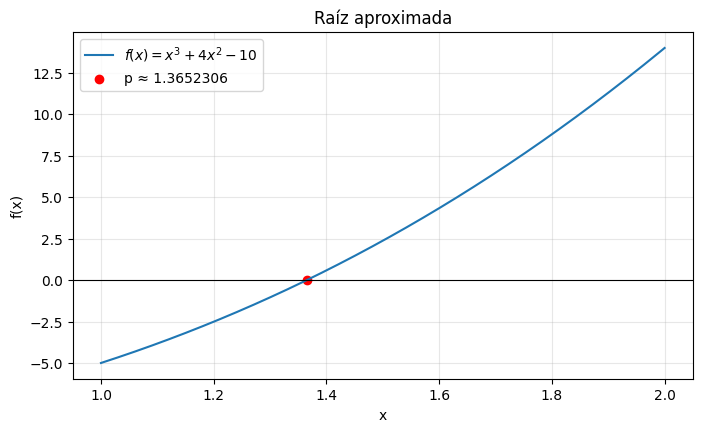

In [7]:

x = np.linspace(1, 2, 300)

plt.figure(figsize=(8, 4.5))
plt.plot(x, f(x), label=r"$f(x)=x^3+4x^2-10$")
plt.axhline(0, color="black", linewidth=0.8)
plt.scatter(raiz, f(raiz), color="red", label=f"p ≈ {raiz:.7f}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Raíz aproximada")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 9. Resultado

$$
\boxed{p\approx 1.36523}
$$

La iteración de punto fijo usa $p_n=g(p_{n-1})$ hasta que la diferencia entre dos aproximaciones es menor que la tolerancia. Con la opción (d) de Burden y $p_0=1.5$, las aproximaciones se acercan a la raíz positiva de $x^3+4x^2-10=0$.
